In [1]:
import pandas as pd


In [2]:
df = pd.read_sas('CY08MSP_STU_QQQ.SAS7BDAT')# The SAS file is loaded more efficientyl than  the SPSS file

The ICT indices are based on student responses to questions about their access to and use of information and communication technologies (ICT) for schoolwork and at home. The indices are constructed using item response theory (IRT) scaling techniques to create standardized scores that reflect students' ICT experiences.

Example: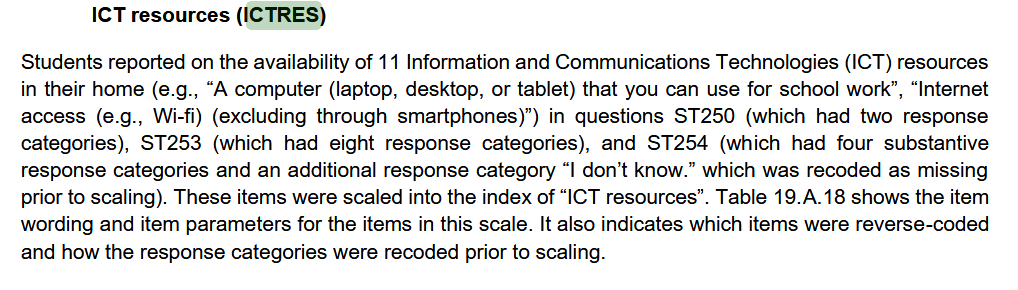

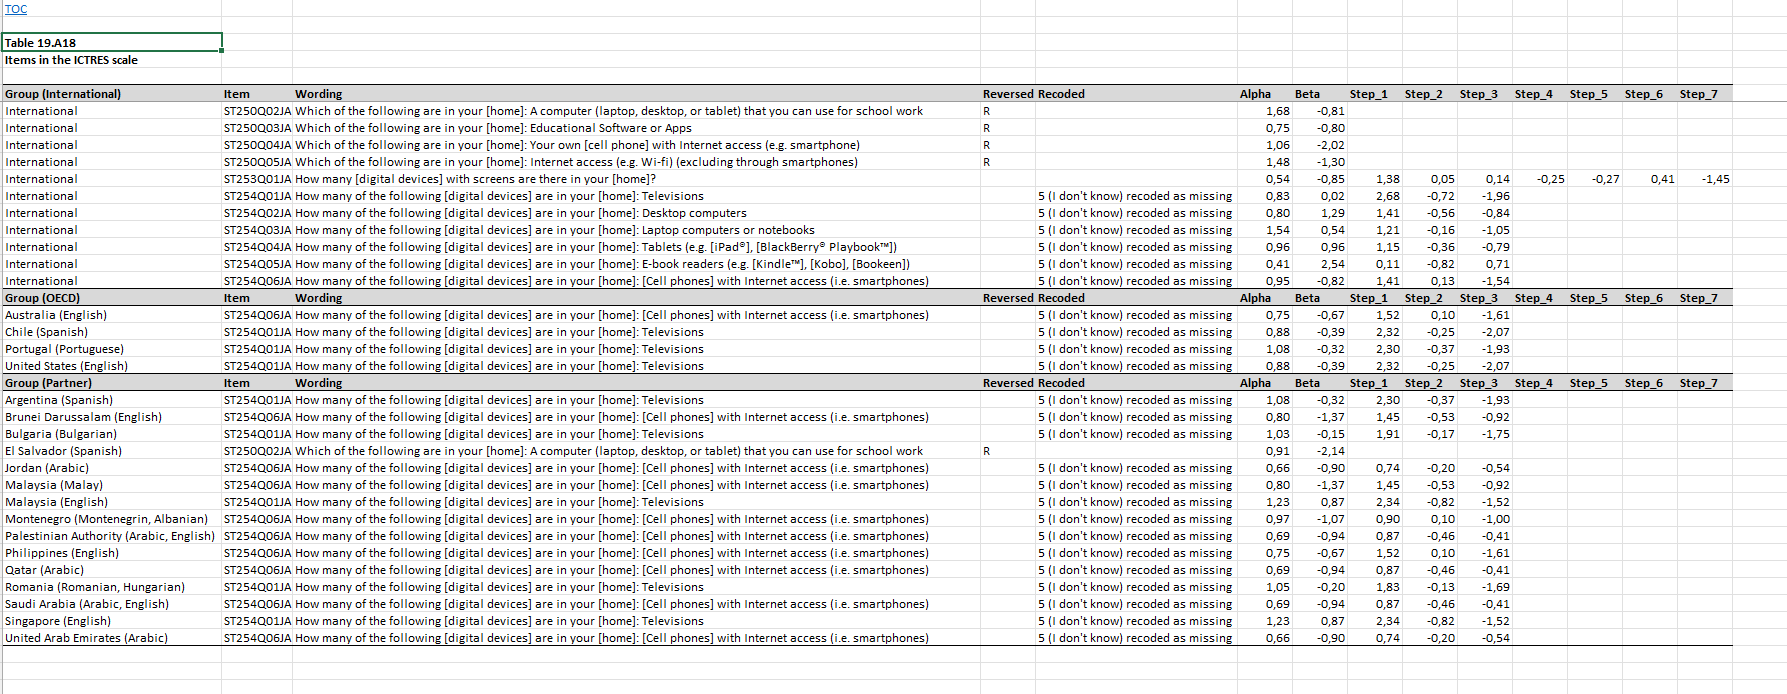

In [6]:
variables = ['CNTSTUID','ESCS','ST004D01T', 'ICTRES', 'ICTSCH','ICTHOME','ICTAVHOM','W_FSTUWT','ICTINFO','ICTQUAL','IMAGINE','CREATHME','MATHPERS','FAMSUPSL']
data = df[variables].copy()

Some indices show bizarre frequency distribution: (I'm not sure if this is expected)

In [7]:
data['FAMSUPSL'].value_counts(dropna=False)

FAMSUPSL
 NaN       258299
-1.2300      1058
 2.4895       979
-1.4799       972
-1.3931       955
            ...  
 0.3869         1
 1.0195         1
-1.0380         1
 1.2095         1
-1.5138         1
Name: count, Length: 21067, dtype: int64

But the index ICTRES seems reasonable:

In [19]:
data['ICTRES'].value_counts(dropna=False)

ICTRES
 NaN       262885
-0.2035      2866
-0.4979      2436
-0.5542      1990
-0.8053      1916
            ...  
-2.1629         1
-1.9983         1
-1.4852         1
-2.4919         1
-2.4933         1
Name: count, Length: 40460, dtype: int64

In [20]:
data = data[data['ICTRES'].notna()]

In [21]:
data.shape

(350859, 13)

Let's combine with the creative thinking score:

In [22]:
df2 = pd.read_sas('CY08MSP_CRT_COG.SAS7BDAT')

In [23]:
data2 = df2[['CNTSTUID','PV1CRTH_NC']]

In [24]:
data2.shape

(499843, 2)

In [25]:
data2['PV1CRTH_NC'].value_counts(dropna=False)

PV1CRTH_NC
29.2    1365
26.8    1347
29.1    1324
29.6    1323
29.0    1318
        ... 
59.2       1
58.3       1
59.3       1
58.5       1
58.9       1
Name: count, Length: 588, dtype: int64

In [29]:
final_df = pd.merge(data, data2, on='CNTSTUID', how='inner')

In [30]:
final_df.shape

(277584, 14)

Let's perform a least squares regression analysis to see how ICTRES predicts creative thinking scores.

In [31]:
import numpy as np
import statsmodels.formula.api as smf

cols = ['PV1CRTH_NC', 'ICTRES', 'ESCS', 'ST004D01T', 'W_FSTUWT']
mod_df = final_df[cols].dropna().copy()

mod_df['ICTRES_SQ'] = mod_df['ICTRES'] ** 2 # Create a squared term for ICTRES to verify if there is an optimal level of ICT resources

mod_df['MALE'] = mod_df['ST004D01T'].map({1: 0, 2: 1})

formula = 'PV1CRTH_NC ~ ICTRES + ICTRES_SQ + ESCS + MALE'

model = smf.wls(formula=formula, data=mod_df, weights=mod_df['W_FSTUWT'])
results = model.fit()

print(results.summary())

                            WLS Regression Results                            
Dep. Variable:             PV1CRTH_NC   R-squared:                       0.230
Model:                            WLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                 2.050e+04
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        07:06:21   Log-Likelihood:            -1.2303e+06
No. Observations:              274899   AIC:                         2.461e+06
Df Residuals:                  274894   BIC:                         2.461e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6929      0.038    806.808      0.0